In [5]:

# Three-Dimensional Rotations: Visualizing the Cube

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# 3D ROTATION MATRICES
def rotation_3d_x(angle_degrees):
    """Rotation around X axis"""
    theta = np.radians(angle_degrees)
    return np.array([
        [1, 0,              0             ],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta),  np.cos(theta)]
    ])

def rotation_3d_y(angle_degrees):
    """Rotation around Y axis"""
    theta = np.radians(angle_degrees)
    return np.array([
        [ np.cos(theta), 0, np.sin(theta)],
        [ 0,             1, 0            ],
        [-np.sin(theta), 0, np.cos(theta)]
    ])

def rotation_3d_z(angle_degrees):
    """Rotation around Z axis"""
    theta = np.radians(angle_degrees)
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])

print("3D Rotation functions created!")
print("\nRotation around X axis (30°):")
print(rotation_3d_x(30))
print()
print("\nRotation around Y axis (30°):")
print(rotation_3d_y(30))
print("\nRotation around Z axis (30°):")
print(rotation_3d_z(30))

3D Rotation functions created!

Rotation around X axis (30°):
[[ 1.         0.         0.       ]
 [ 0.         0.8660254 -0.5      ]
 [ 0.         0.5        0.8660254]]


Rotation around Y axis (30°):
[[ 0.8660254  0.         0.5      ]
 [ 0.         1.         0.       ]
 [-0.5        0.         0.8660254]]

Rotation around Z axis (30°):
[[ 0.8660254 -0.5        0.       ]
 [ 0.5        0.8660254  0.       ]
 [ 0.         0.         1.       ]]


In [7]:

# CREATE A CUBE

def create_cube():
    """Create a unit cube with 8 vertices"""
    # 8 corners of a cube
    vertices = np.array([
        [0, 0, 0],  # 0: origin
        [1, 0, 0],  # 1: +X
        [1, 1, 0],  # 2: +X, +Y
        [0, 1, 0],  # 3: +Y
        [0, 0, 1],  # 4: +Z
        [1, 0, 1],  # 5: +X, +Z
        [1, 1, 1],  # 6: +X, +Y, +Z
        [0, 1, 1]   # 7: +Y, +Z
    ]).T  # Transpose to get 3×8 matrix

    return vertices


cube = create_cube()
print(f"Shape: {cube.shape}")
print(f"\nFirst vertex (origin): {cube[:, 0]}")
print(f"Last vertex (opposite corner): {cube[:, 6]}")

Shape: (3, 8)

First vertex (origin): [0 0 0]
Last vertex (opposite corner): [1 1 1]


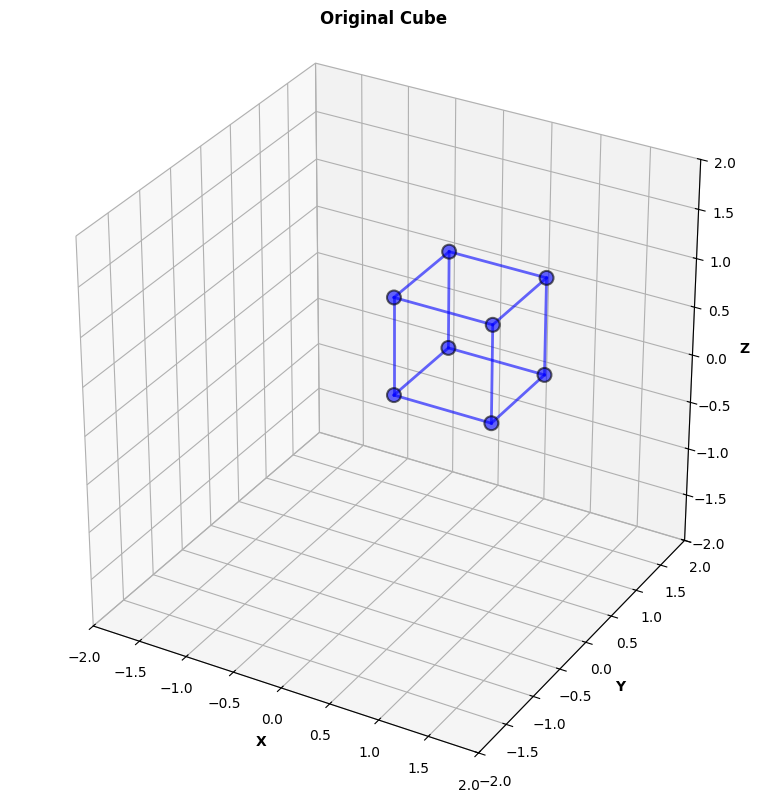

In [10]:

# 3D VISUALIZATION FUNCTION

def plot_cube_3d(vertices, ax, color='blue', alpha=0.6, title='Cube'):

    # Draw vertices (corners)
    ax.scatter(vertices[0], vertices[1], vertices[2],
               c=color, s=100, alpha=alpha, edgecolors='black', linewidth=1.5)

    edges = [
        [0, 1], [1, 2], [2, 3], [3, 0],
        [4, 5], [5, 6], [6, 7], [7, 4],
        [0, 4], [1, 5], [2, 6], [3, 7]
    ]

    for edge in edges:
        points = vertices[:, edge]
        ax.plot3D(points[0], points[1], points[2],
                  color=color, linewidth=2, alpha=alpha)

    # Settings
    ax.set_xlim([-2, 2])
    ax.set_ylim([-2, 2])
    ax.set_zlim([-2, 2])
    ax.set_xlabel('X', fontsize=10, fontweight='bold')
    ax.set_ylabel('Y', fontsize=10, fontweight='bold')
    ax.set_zlabel('Z', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_box_aspect([1,1,1])




cube = create_cube()
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')


plot_cube_3d(cube, ax, color='blue', title='Original Cube')


plt.tight_layout()
plt.show()



In [11]:

# PART 5: APPLY TRANSFORMATIONS

cube = create_cube()
# Apply rotations
cube_x = rotation_3d_x(30) @ cube
cube_y = rotation_3d_y(45) @ cube
cube_z = rotation_3d_z(60) @ cube

# Combined rotation
R_combined = rotation_3d_x(30) @ rotation_3d_y(45) @ rotation_3d_z(60)
cube_combined = R_combined @ cube

print(f"\nOriginal corner: {cube[:, 0]}")
print(f"After X rotation: {cube_x[:, 0]}")
print(f"After Y rotation: {cube_y[:, 0]}")
print(f"After Z rotation: {cube_z[:, 0]}")


Original corner: [0 0 0]
After X rotation: [0. 0. 0.]
After Y rotation: [0. 0. 0.]
After Z rotation: [0. 0. 0.]


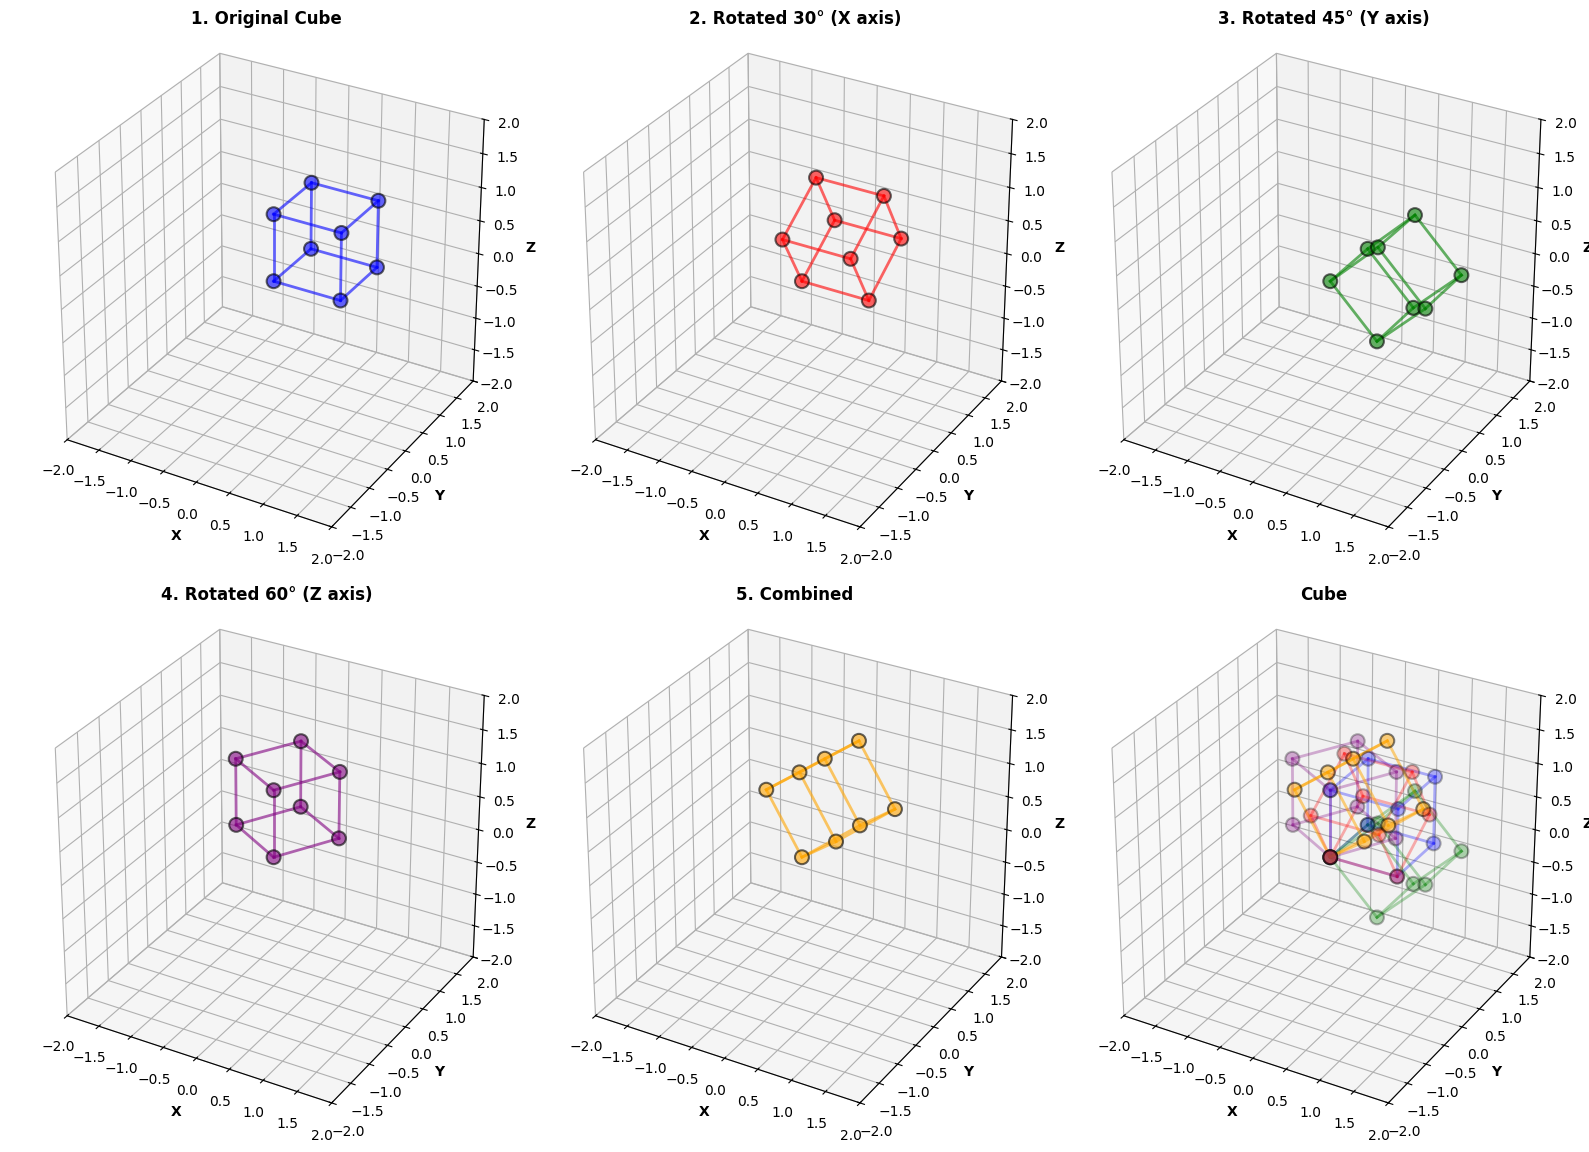

In [13]:

# PART 6: COMPARE ALL TRANSFORMATIONS

fig = plt.figure(figsize=(16, 12))

# 1. Original
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
plot_cube_3d(cube, ax1, color='blue', title='1. Original Cube')

# 2. X rotation
ax2 = fig.add_subplot(2, 3, 2, projection='3d')
plot_cube_3d(cube_x, ax2, color='red', title='2. Rotated 30° (X axis)')

# 3. Y rotation
ax3 = fig.add_subplot(2, 3, 3, projection='3d')
plot_cube_3d(cube_y, ax3, color='green', title='3. Rotated 45° (Y axis)')

# 4. Z rotation
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
plot_cube_3d(cube_z, ax4, color='purple', title='4. Rotated 60° (Z axis)')

# 5. Combined
ax5 = fig.add_subplot(2, 3, 5, projection='3d')
plot_cube_3d(cube_combined, ax5, color='orange',
             title='5. Combined')

# 6. All together
ax6 = fig.add_subplot(2, 3, 6, projection='3d')
plot_cube_3d(cube, ax6, color='blue', alpha=0.3, title='6. All Together')
plot_cube_3d(cube_x, ax6, color='red', alpha=0.3)
plot_cube_3d(cube_y, ax6, color='green', alpha=0.3)
plot_cube_3d(cube_z, ax6, color='purple', alpha=0.3)
plot_cube_3d(cube_combined, ax6, color='orange', alpha=0.5)

plt.tight_layout()
plt.show()